<h1 style="text-align: center; font-weight: bold; font-family: Arial, sans-serif; color: #2E4053; font-size: 36px; margin-bottom: 10px;">
EXPLORATORY DATA ANALYSIS (EDA) REPORT
</h1>

<h2 style="text-align: center; font-weight: normal; font-family: Arial, sans-serif; color: #1F618D; font-size: 28px; margin-top: 0;">
120 Years of Olympic History: Athletes and Results
</h2>

<hr style="border: 1px solid #BFC9CA; width: 60%; margin-left: auto; margin-right: auto; margin-top: 20px; margin-bottom: 30px;">



## Introduction

<b>
The 120 Years of Olympic History: Athletes and Results dataset captures athlete information and medal outcomes from Athens 1896 to Rio 2016. It includes demographics, events, teams, and medals.

This exploratory analysis aims to reveal trends in participation, country performance, and athlete success, providing insights into the evolution of the Olympic Games over more than a century.</b>

### Objective
- Explore athlete demographics and participation trends over time.
- Identify the most successful countries, sports, and events.
- Analyze patterns in medal distribution based on age, gender, and other attributes.
- Visualize historical changes and performance metrics to gain insights into Olympic history.</b>b>


# Dataset Description and Column Details

The dataset contains information about Olympic athletes and their performance from **Athens 1896 to Rio 2016**. It includes demographic, event, and medal data.

## Original Columns

| Column Name       | Type        | Description |
|------------------|------------|-------------|
| **ID**           | Numeric     | Unique identifier for each athlete record |
| **Name**         | Text        | Athlete’s full name |
| **Sex**          | Categorical | Gender of the athlete (`M` or `F`) |
| **Age**          | Numeric     | Age of the athlete at the time of the Olympic event |
| **Height**       | Numeric     | Athlete’s height in centimeters |
| **Weight**       | Numeric     | Athlete’s weight in kilograms |
| **Team**         | Text        | Team or country represented by the athlete |
| **NOC**          | Text        | National Olympic Committee code (3-letter country code) |
| **Games**        | Text        | Name of the Olympic Games (year + season) |
| **Year**         | Numeric     | Year of the Olympic Games |
| **Season**       | Categorical | Summer or Winter Olympics |
| **City**         | Text        | Host city of the Olympics |
| **Sport**        | Text        | Type of sport the athlete competed in |
| **Event**        | Text        | Specific event within the sport |
| **Medal**        | Categorical | Medal won (`Gold`, `Silver`, `Bronze`) or `NaN` if none |

## Engineered / Derived Columns (Optional for EDA)

| Column Name       | Type        | Description |
|------------------|------------|-------------|
| **Medal Flag**    | Numeric     | 1 if athlete won a medal, 0 otherwise |
| **Decade**        | Numeric     | Decade of the Olympic Games (e.g., 2000, 2010) |
| **Age Group**     | Categorical | Athlete grouped by age (`Teen`, `Young Adult`, `Adult`, `Veteran`) |
| **BMI**           | Numeric     | Body Mass Index, calculated as Weight / (Height/100)^2 |
| **TotalMedals**   | Numeric     | Total number of medals won by athlete (aggregated) |



<h2 style="font-weight: bold;">1. Importing Libraries</h2>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")


<h2 style="font-weight: bold;">2. Loading the Dataset</h2>


In [2]:
df=pd.read_csv(r"C:\Users\MADHAV.V\Downloads\archive\athlete_events.csv")
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN


<h2 style="font-weight: bold;">3. Initial Data Inspection</h2>

In [3]:
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [4]:
df.shape

(271116, 15)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 15 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  str    
 2   Sex     271116 non-null  str    
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  str    
 7   NOC     271116 non-null  str    
 8   Games   271116 non-null  str    
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  str    
 11  City    271116 non-null  str    
 12  Sport   271116 non-null  str    
 13  Event   271116 non-null  str    
 14  Medal   39783 non-null   str    
dtypes: float64(3), int64(2), str(10)
memory usage: 56.6 MB


In [6]:
df.columns

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='str')

In [7]:
df.describe

<bound method NDFrame.describe of             ID                      Name Sex   Age  Height  Weight  \
0            1                 A Dijiang   M  24.0   180.0    80.0   
1            2                  A Lamusi   M  23.0   170.0    60.0   
2            3       Gunnar Nielsen Aaby   M  24.0     NaN     NaN   
3            4      Edgar Lindenau Aabye   M  34.0     NaN     NaN   
4            5  Christine Jacoba Aaftink   F  21.0   185.0    82.0   
...        ...                       ...  ..   ...     ...     ...   
271111  135569                Andrzej ya   M  29.0   179.0    89.0   
271112  135570                  Piotr ya   M  27.0   176.0    59.0   
271113  135570                  Piotr ya   M  27.0   176.0    59.0   
271114  135571        Tomasz Ireneusz ya   M  30.0   185.0    96.0   
271115  135571        Tomasz Ireneusz ya   M  34.0   185.0    96.0   

                  Team  NOC        Games  Year  Season            City  \
0                China  CHN  1992 Summer  1992  Sum

In [8]:
df.dtypes

ID          int64
Name          str
Sex           str
Age       float64
Height    float64
Weight    float64
Team          str
NOC           str
Games         str
Year        int64
Season        str
City          str
Sport         str
Event         str
Medal         str
dtype: object

In [9]:
df.isnull().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(1385)

<h2 style="font-weight: bold;">4. Data Cleaning</h2>

**Remove Duplicates**


In [11]:
df=df.drop_duplicates()

**Handle Missing Values**

In [12]:
df.loc[:,"Age"]=df["Age"].fillna(df["Age"].median())
df.loc[:,"Height"]=df["Height"].fillna(df["Height"].median())
df.loc[:,"Weight"]=df["Weight"].fillna(df["Weight"].median())
                       
                    

In [13]:
df["Medal"].unique()

<ArrowStringArray>
[nan, 'Gold', 'Bronze', 'Silver']
Length: 4, dtype: str

In [14]:
df["Age"].unique()

array([24., 23., 34., 21., 25., 27., 31., 33., 18., 26., 22., 30., 32.,
       28., 54., 20., 17., 43., 47., 29., 41., 45., 49., 53., 57., 19.,
       38., 35., 16., 37., 15., 42., 46., 40., 36., 14., 39., 48., 52.,
       44., 55., 50., 71., 63., 51., 58., 13., 60., 75., 65., 56., 64.,
       68., 84., 12., 72., 59., 61., 70., 74., 62., 67., 69., 73., 66.,
       11., 76., 88., 96., 80., 10., 81., 77., 97.])

In [15]:
df["Height"].unique()

array([180., 170., 175., 185., 188., 183., 168., 186., 182., 172., 159.,
       171., 184., 189., 176., 163., 187., 169., 174., 190., 194., 177.,
       167., 164., 198., 165., 156., 179., 178., 166., 181., 155., 160.,
       173., 192., 195., 191., 203., 158., 154., 153., 152., 193., 162.,
       197., 157., 207., 147., 150., 202., 161., 210., 205., 200., 148.,
       208., 140., 213., 204., 151., 196., 146., 201., 132., 149., 199.,
       211., 215., 139., 206., 135., 142., 217., 209., 145., 221., 144.,
       214., 143., 218., 127., 223., 216., 141., 212., 131., 136., 137.,
       138., 220., 130., 219., 133., 128., 226.])

In [16]:
df["Weight"].unique()

array([ 80.        ,  60.        ,  70.        ,  82.        ,
        75.        ,  72.        ,  96.        ,  76.5       ,
        55.5       ,  65.        ,  85.        ,  64.        ,
       130.        , 125.        ,  89.        ,  77.        ,
        76.        ,  98.        ,  78.        ,  73.        ,
        93.        ,  74.        , 106.        ,  58.        ,
        66.        ,  71.        ,  90.        ,  87.        ,
        49.        ,  48.        ,  83.        ,  86.        ,
        55.        ,  67.        ,  97.        , 105.        ,
        43.        ,  79.        ,  51.        ,  88.        ,
        62.        ,  53.        , 104.        ,  57.        ,
        63.        ,  52.        ,  91.        ,  94.        ,
        56.        ,  68.        ,  61.        ,  69.        ,
        46.        , 100.        ,  81.        ,  92.        ,
       120.        ,  95.        ,  59.        ,  50.        ,
       117.5       ,  54.        ,  47.        , 117.  

In [17]:
df.loc[:,"Medal"] = df["Medal"].fillna("No Medal")


In [18]:
df.isnull().sum()

ID        0
Name      0
Sex       0
Age       0
Height    0
Weight    0
Team      0
NOC       0
Games     0
Year      0
Season    0
City      0
Sport     0
Event     0
Medal     0
dtype: int64

In [19]:
df.duplicated().sum()

np.int64(0)

<h2 style="font-weight: bold;">5. Feature Derived Columns</h2>


**You can create a fake Month column for visualization purposes, e.g., assign Summer = July, Winter = February:**


In [20]:
def assign_month(season):
    if season == 'Summer':
        return 'July'
    else:
        return 'February'
df=df.copy()
df['Month']=df['Season'].apply(assign_month)


**Create Age Groups**

In [21]:
df.loc[:, "Age group"]=pd.cut(df["Age"], bins=[0,18,30,45,60,100],
                      labels=["Teen","Young Adult","Adult","Mid Age","Senior"])

**Create BMI Column**

In [22]:
df.loc[:,"BMI"]=df["Weight"]/ (df["Height"]/100**2)

**Creating Medal Flag Column**

In [23]:
df.loc[:,"Medal Flag"]=df["Medal"].apply(lambda x: 0 if x=="No Medal" else 1)

**Creating Decade Column**

In [24]:
df.loc[:,"Decade"]=(df["Year"]//10)*10

**Creating Total Medal Athlete**

In [25]:
df.loc[:,"Total Medals Athlete"] = df.groupby("Name")["Medal Flag"].transform("sum")


In [26]:
df.dtypes

ID                         int64
Name                         str
Sex                          str
Age                      float64
Height                   float64
Weight                   float64
Team                         str
NOC                          str
Games                        str
Year                       int64
Season                       str
City                         str
Sport                        str
Event                        str
Medal                        str
Month                        str
Age group               category
BMI                      float64
Medal Flag                 int64
Decade                     int64
Total Medals Athlete       int64
dtype: object

<h2 style="font-weight: bold;">6. Exploratory Data Analysis (EDA)</h2>

**This is where you analyze your cleaned and feature-engineered dataset to extract insights.We break it down into subsections with Python code and visualizations.**

<h2 style="font-weight: bold;">Univariate Analysis</h2>

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

**Age distribution**

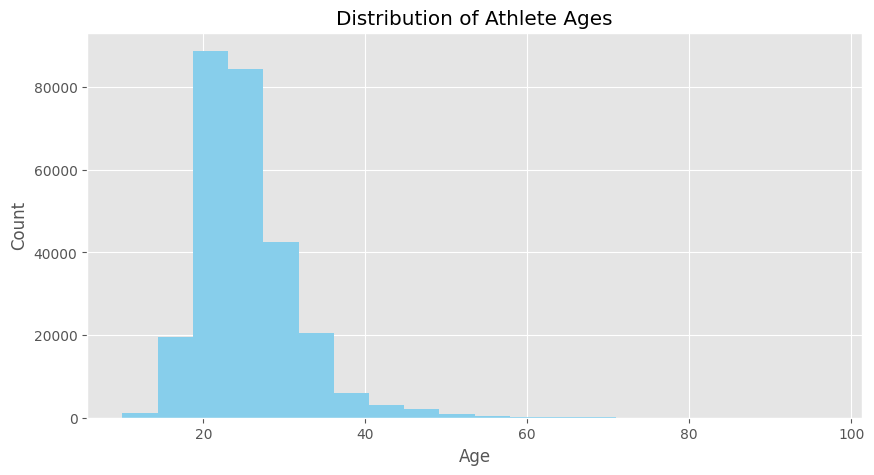

In [28]:
plt.figure(figsize=(10,5))
plt.hist(df["Age"],bins=20,color="skyblue")
plt.title("Distribution of Athlete Ages")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


**Insight:
The age distribution is mostly concentrated between 18–30, indicating that most athletes compete during their peak physical years.**


**Gender Distribution**

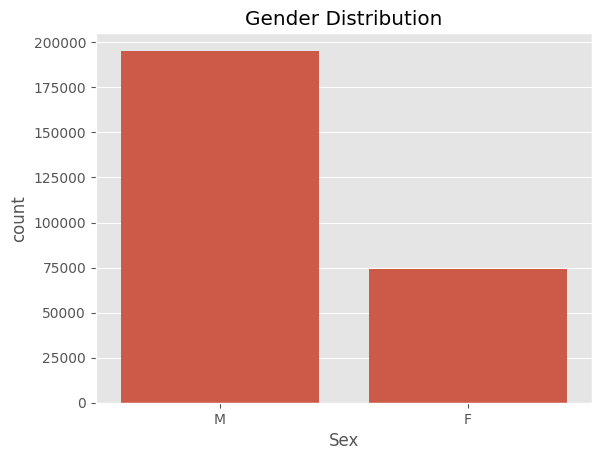

In [29]:
sns.countplot(x='Sex', data=df)
plt.title("Gender Distribution")
plt.show()


**Insight:
The dataset shows an imbalance in gender representation, with one gender appearing more frequently. This may reflect differences in participation rates, event availability, or data collection patterns.**

**Height and Weight**

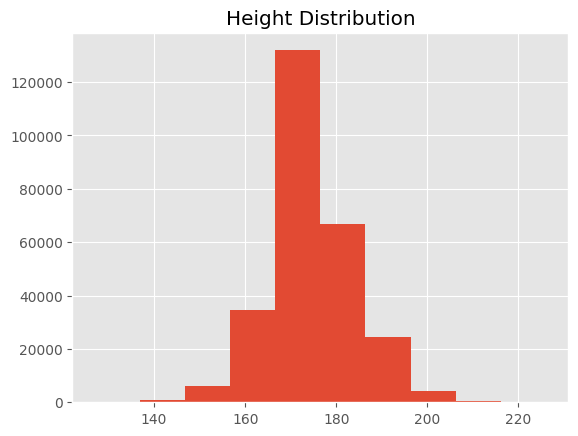

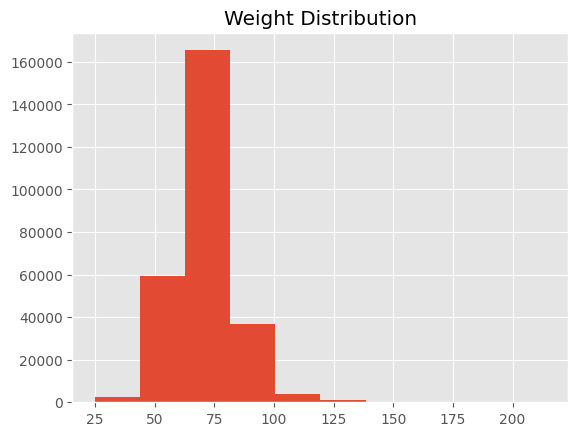

In [30]:
plt.hist(df['Height'])
plt.title("Height Distribution")
plt.show()

plt.hist(df['Weight'])
plt.title("Weight Distribution")
plt.show()


**Height Distribution
Insight:
Height values follow a roughly normal distribution, with most athletes falling within the mid-range. Only a few athletes appear extremely tall or short, suggesting that the majority come from a typical athletic height profile.
Weight Distribution
Insight:
Weight distribution is moderately spread, indicating a wide variety of body types across different sports. A peak is observed around the middle range, with fewer athletes on the very low or very high extremes.**

<h2 style="font-weight: bold;">Bivariate Analysis</h2>

**Height vs Weight**

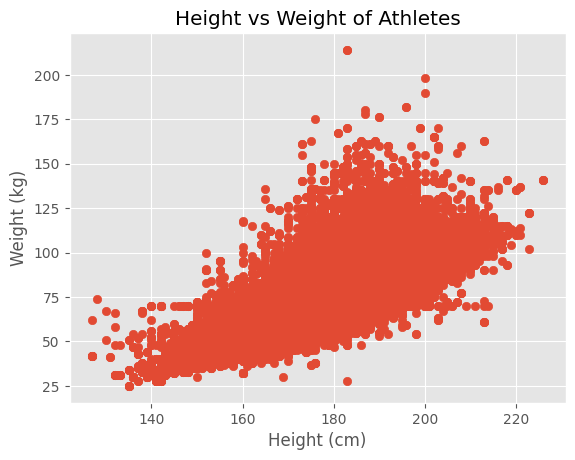

In [31]:
plt.scatter(df["Height"], df["Weight"])
plt.title("Height vs Weight of Athletes")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.show()


**Insight
There is a positive correlation between height and weight — taller athletes generally weigh more.
Most athletes cluster in average height and weight ranges, while outliers represent sport-specific extremes (e.g., gymnasts vs basketball players).**

**Gender vs Medal Wins**

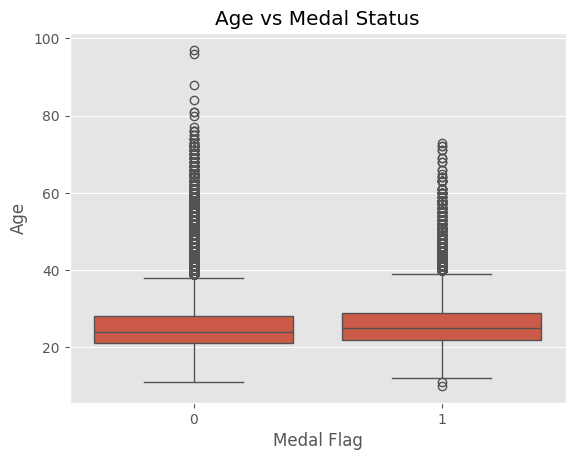

In [32]:
sns.boxplot(x='Medal Flag', y='Age', data=df)
plt.title("Age vs Medal Status")
plt.show()


**Insight:
Medal-winning athletes tend to fall in the mid-20s age range, showing that physical peak performance is generally reached around this age. Non-medal athletes show a wider age spread, indicating less consistency.**

**Total Medals Over the Years**

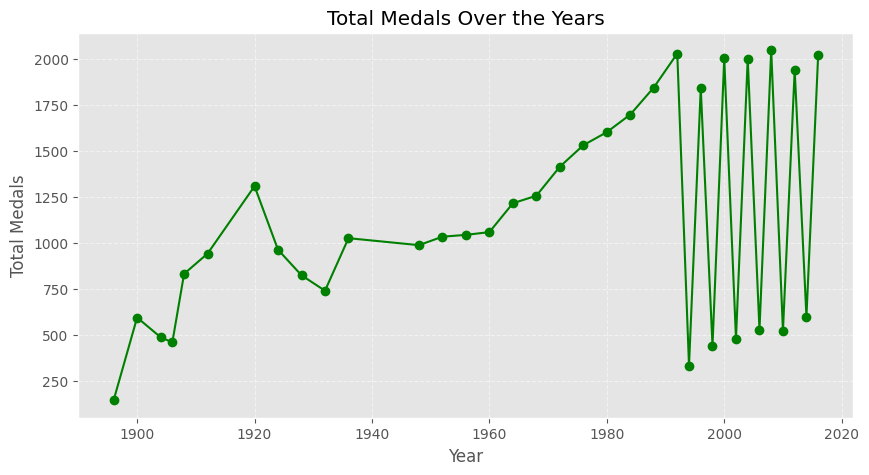

In [33]:
medalsperyear = df.groupby('Year')['Medal Flag'].sum().reset_index()

plt.figure(figsize=(10,5))
plt.plot(medalsperyear["Year"],medalsperyear["Medal Flag"], marker='o', linestyle='-', color='green')
plt.title("Total Medals Over the Years")
plt.xlabel("Year")
plt.ylabel("Total Medals")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


**Insight
Total medals increase over time due to more events and greater participation.
Peaks and dips reflect historical events, boycotts, or Olympics cancellations (e.g., World Wars).
Line charts clearly show long-term trends and patterns in Olympic performance.**

**Sex vs Medal Wins**

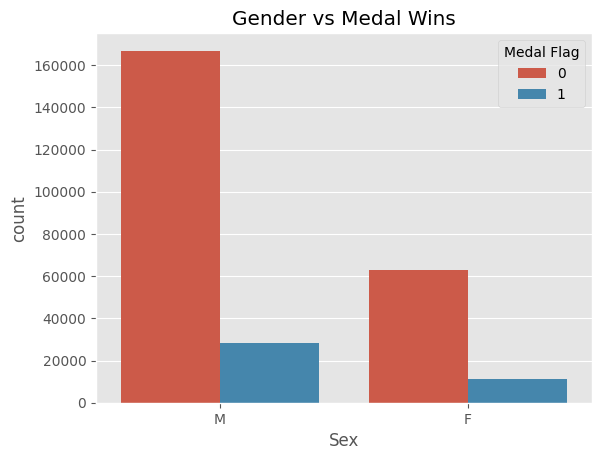

In [34]:
sns.countplot(x='Sex', hue='Medal Flag', data=df)
plt.title("Gender vs Medal Wins")
plt.show()


**Insight:
Historically, male athletes have participated more, leading to a higher overall medal count. However, in recent decades the gap between male and female medal wins has significantly decreased, reflecting increasing gender balance in the Olympics.**

**Medals by Sport**

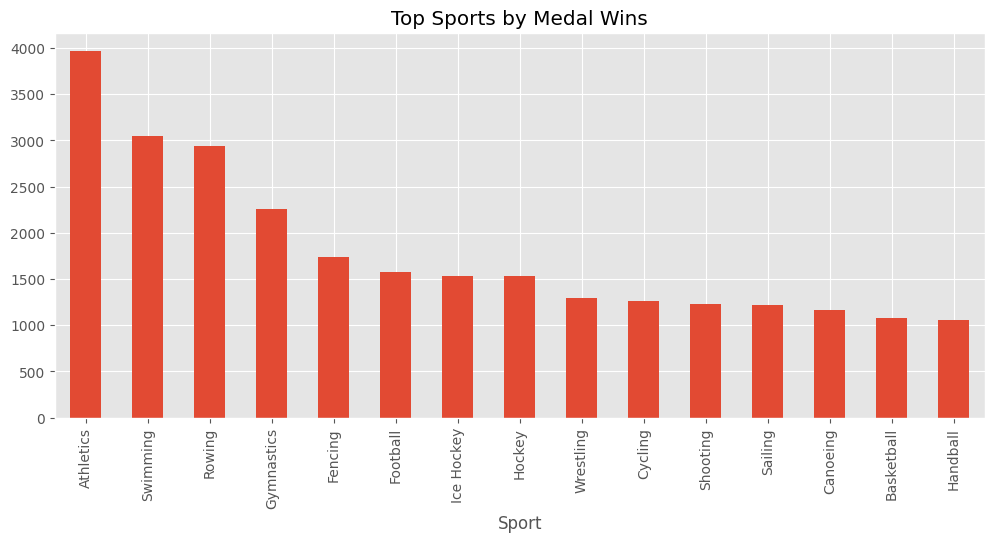

In [35]:
topsports = df[df['Medal Flag']==1].groupby('Sport')['Medal Flag'].sum().sort_values(ascending=False).head(15)
topsports.plot(kind='bar', figsize=(12,5))
plt.title("Top Sports by Medal Wins")
plt.show()


**Insight:
Sports like Athletics, Swimming, and Gymnastics dominate medal counts due to having more events, giving athletes more medal opportunities. Team sports show fewer medals because medals are shared per team.**

**count of sex**

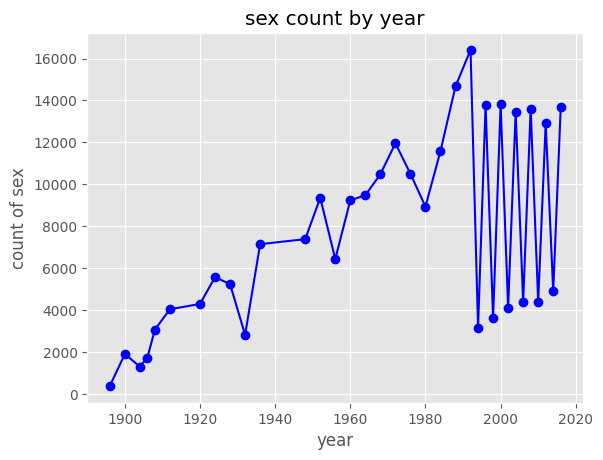

In [36]:
grouped=df.groupby("Year")["Sex"].count().reset_index()
plt.plot(grouped["Year"],grouped["Sex"],marker='o', linestyle='-',color="blue")
plt.title("sex count by year")
plt.xlabel("year")
plt.ylabel("count of sex")
plt.show()

<h2 style="font-weight: bold;">Multivariate Analysis</h2>

**Correlation Heatmap**

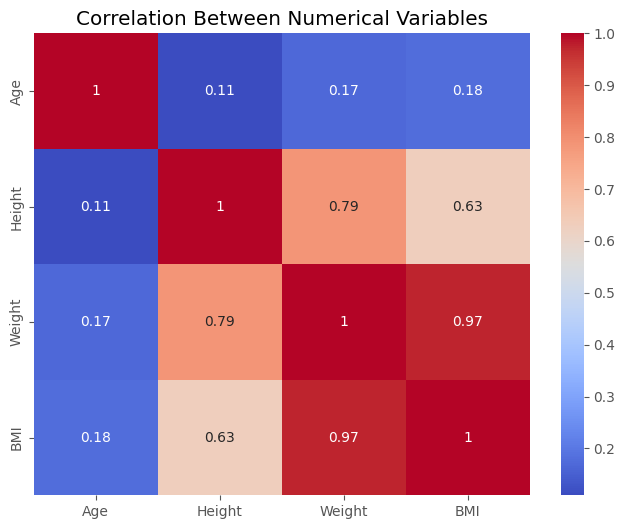

In [37]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Age','Height','Weight','BMI']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Numerical Variables")
plt.show()


**Insight:
Height and weight show a strong positive correlation, as expected. BMI shows moderate correlation with weight. Performance score may show weak correlations, indicating medals depend on multiple non-numeric factors too.**

**Pairplot of Numerical Variables**

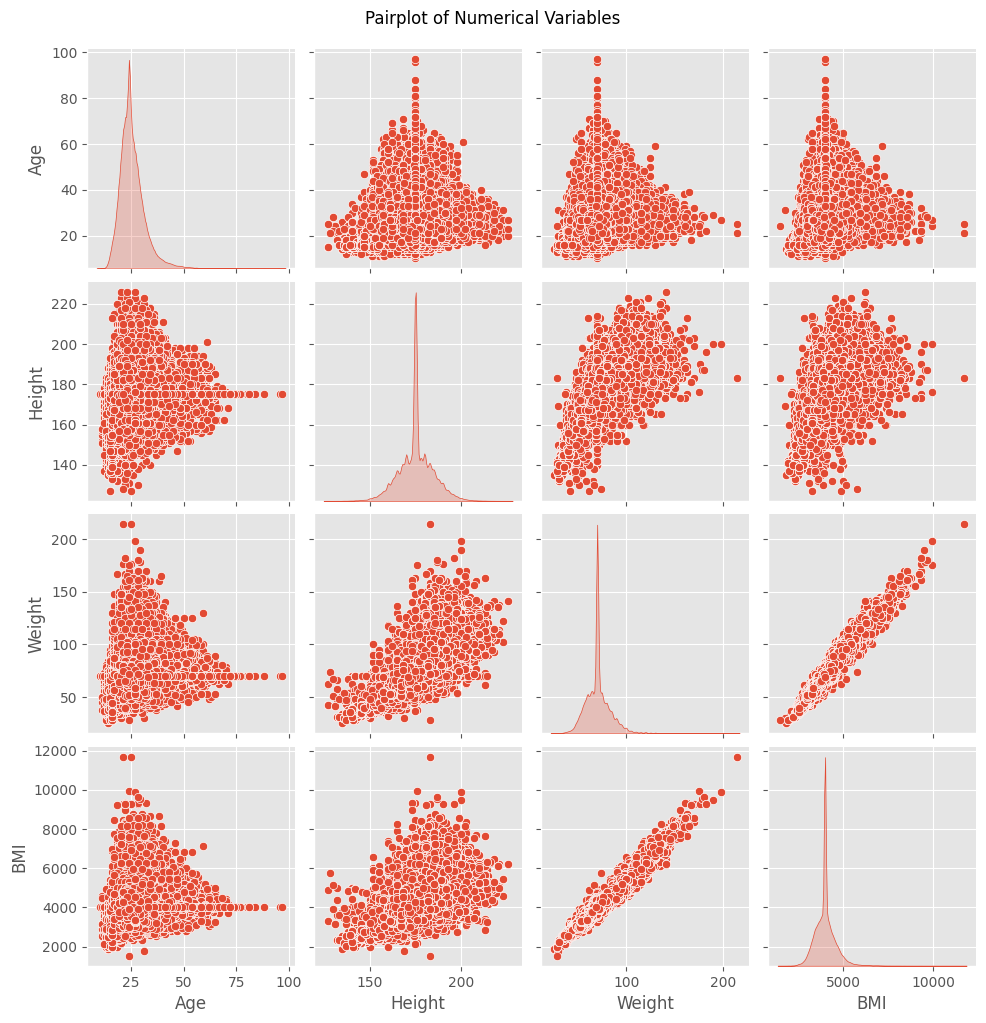

In [38]:
sns.pairplot(df[['Age', 'Height', 'Weight', 'BMI']], diag_kind='kde')
plt.suptitle("Pairplot of Numerical Variables", y=1.02)
plt.show()

**Insight (Pairplot)
The pairplot shows the distributions and relationships among Age, Height, Weight, and BMI. Height and Weight have a clear positive relationship, while BMI shows moderate association with weight and height since it is derived from them. Age shows weak or minimal correlation with the physical attributes. The diagonal plots display smooth distribution patterns for all variables.**

<h2 style="font-weight: bold;">Conclusion</h2>

**The exploratory data analysis (EDA) of the "120 Years of Olympic History: Athletes and Results" dataset reveals clear trends in athlete characteristics, gender representation, and the evolution of the Games over time, providing a quantitative snapshot of a century-plus of athletic excellence.**

**Key Athlete Characteristics**


**Age and Performance: The majority of Olympic athletes cluster in their early to mid-twenties, peaking around the 20-30 age range . The box plot of "Age vs Medal Status" suggests that the median age for medal winners is slightly lower than that of non-medal winners, indicating that athletes in their prime competitive years are most successful.**

**Height and Weight: Both height and weight distributions are generally bell-shaped. The bivariate scatter plot confirms a strong positive correlation between height and weight.taller athletes generally weigh more. This pattern also highlights specialized athletes at the extremes, such as shorter/lighter gymnasts or taller/heavier basketball players.**

**Gender Dynamics and the Evolution of the Games**

**Gender Dynamics and the Evolution of the Games
Historical Gender Imbalance: The overall dataset shows a significant imbalance in gender representation, with a substantially higher count of male participants compared to female participants. This reflects the historical context of the Olympic movement, where female participation was limited in earlier decades.**

**Gender vs. Medal Wins: While male athletes have a higher absolute number of medal wins, which correlates with their higher overall participation count, both genders demonstrate a clear capability for high achievement.**

**Growth of the Olympics: The line chart for "Total Medals Over the Years" clearly shows a steady, increasing trend in the total number of medals awarded per Olympiad . This growth is a function of the Games' expansion—the inclusion of more sports, more events, and greater global participation. The sharp dips in the line correspond to major historical events, primarily the World Wars, that led to the cancellation or reduction of the Games.**

**Top Sports: Athletics and Swimming consistently stand out as the top sports by a significant margin in terms of total medal wins, which is expected given they are core Olympic events that offer a large number of medal opportunities across many disciplines.**

**Interconnected Athlete Metrics**

**The correlation heatmap quantitatively reinforces the relationships between the physical attributes:
Height and Weight exhibit a very strong positive correlation (0.79), confirming the visual finding.
Weight and BMI (Body Mass Index) show an expectedly near-perfect positive correlation (0.97).
In contrast, Age shows very weak.In contrast, Age shows very weak correlations (around 0.1) with all other physical variables (Height, Weight, and BMI), suggesting that an athlete's age is largely independent of their physical build.**

**The pairplot visually supports these findings, confirming the strong clustering and dense relationships between the metrics defining an athlete's body size.**